In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("../../data/economic_index.csv")

In [7]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [8]:
# dropping unneccessary data

df.drop(columns=["Unnamed: 0", "year", "month"], inplace=True)

df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [9]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

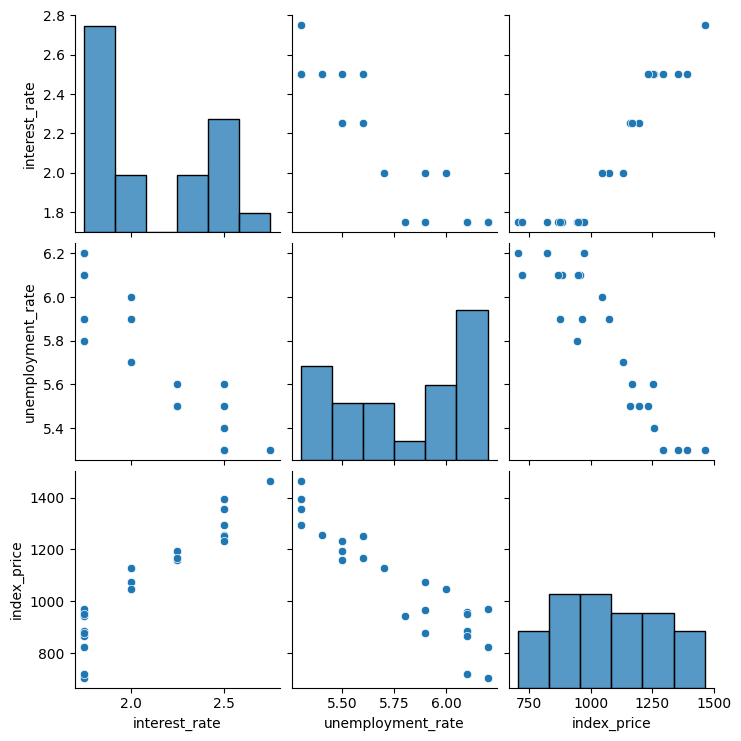

In [12]:
# visualization

import seaborn as sns

sns.pairplot(df)

In [13]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

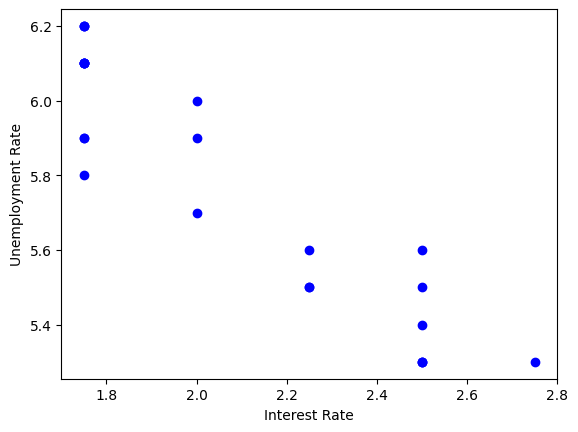

In [15]:
# visualizing datapoints more closely

plt.scatter(df["interest_rate"], df["unemployment_rate"], color='b')

plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

In [17]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [18]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [19]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [44]:
# train test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

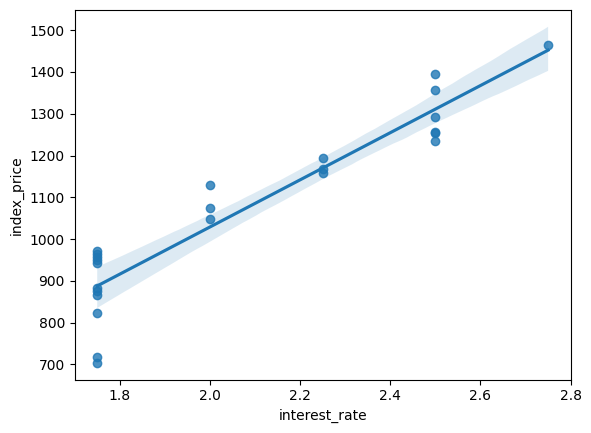

In [22]:

# sns.regplot(df["interest_rate"], df["index_price"])       this has been deprecated

sns.regplot(x=df["interest_rate"], y=df["index_price"])


<Axes: xlabel='unemployment_rate', ylabel='index_price'>

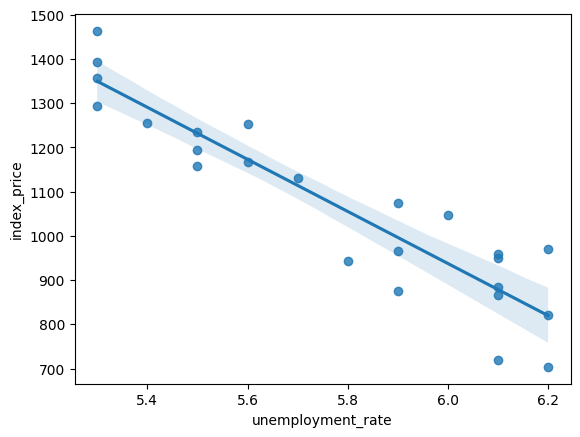

In [23]:
sns.regplot(x=df["unemployment_rate"], y=df["index_price"])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

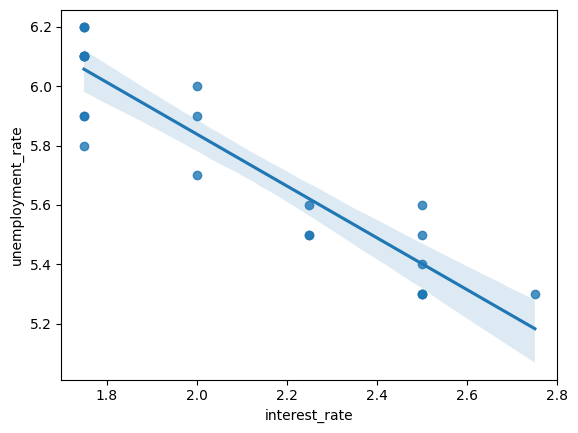

In [25]:
sns.regplot(x=df["interest_rate"], y=df["unemployment_rate"])

In [45]:
# scaling or standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [46]:
x_train

array([[-0.89073374,  1.25707872],
       [ 1.35954097, -0.62853936],
       [ 1.35954097, -1.5713484 ],
       [-0.14064217,  0.62853936],
       [-0.89073374,  0.94280904],
       [ 1.35954097, -1.5713484 ],
       [ 1.35954097, -1.25707872],
       [-0.89073374,  1.25707872],
       [-0.89073374,  0.94280904],
       [-0.89073374,  0.31426968],
       [-0.89073374,  0.94280904],
       [ 0.6094494 , -0.94280904],
       [-0.14064217, -0.31426968],
       [-0.89073374,  0.        ],
       [-0.89073374,  0.94280904],
       [ 1.35954097, -0.94280904]])

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [48]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
# cross validation

from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(model, x_train, y_train, scoring='neg_mean_squared_error', cv=3)

In [50]:
np.mean(validation_score)

np.float64(-8584.447029905596)

In [51]:
# prediction

y_pred = model.predict(x_test)

In [52]:
y_pred

array([1192.13083729,  824.23971817, 1400.41971162,  856.16016713,
        992.22505325, 1160.21038833,  920.00106505, 1328.19572341])

In [53]:
# performance metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

score = r2_score(y_test, y_pred)

"""

adjusted r2 formula:  1 / [(1 - R2) * (n - 1) / (n - k - 1)]

R2: The R2 of the model
n:  The number of observations
k:  The number of predictor variables

"""

n = len(y_test)
k = x_test.shape[1]

adjusted_r2 = 1 - (((1 - score) * (n - 1)) / (n - k - 1))

print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("Root Mean Squared Error:: ", rmse)

print("R2: ", score)
print("Adjusted R2: ", adjusted_r2)

Mean Absolute Error:  58.95987629034907
Mean Squared Error:  5088.329958294002
Root Mean Squared Error::  71.3325308558024
R2:  0.8640024299625206
Adjusted R2:  0.8096034019475289


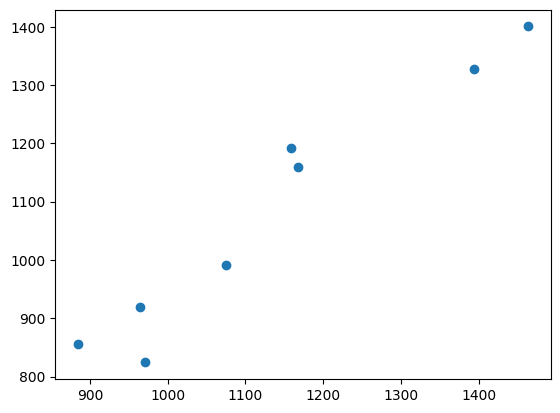

In [55]:
# assumptions

plt.scatter(y_test, y_pred)

In [56]:
residuals = y_test - y_pred

residuals

8     -33.130837
16    146.760282
0      63.580288
18     27.839833
11     82.774947
9       6.789612
13     44.998935
1      65.804277
Name: index_price, dtype: float64

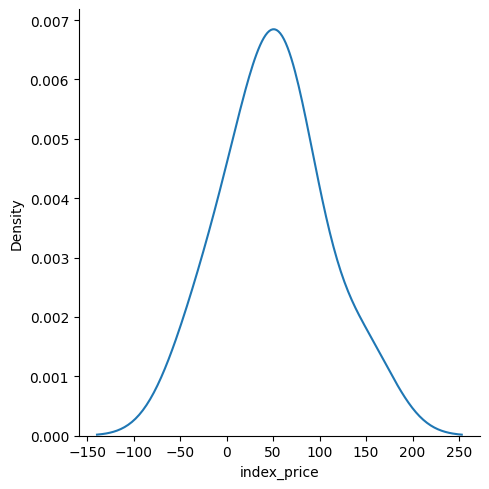

In [57]:
# plotting residuals

sns.displot(residuals, kind="kde")

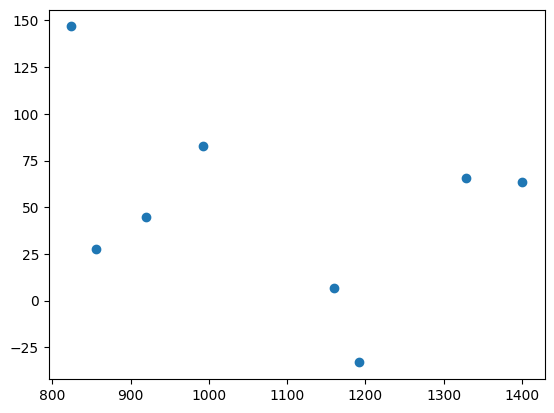

In [58]:
# scatter plot w.r.t prediction & residuals

plt.scatter(y_pred, residuals)

In [62]:
# OLS Linear Regression

import statsmodels.api as sm

model = sm.OLS(y_train, x_train).fit()

In [63]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.105
Method:                 Least Squares   F-statistic:                             0.2425
Date:                Thu, 14 May 2026   Prob (F-statistic):                       0.788
Time:                        19:38:01   Log-Likelihood:                         -133.85
No. Observations:                  16   AIC:                                      271.7
Df Residuals:                      14   BIC:                                      273.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            96.2869    682.952      0.141      0.890   -1368.500    1561.074
x2          -101.5702    682.952     -0.149      0.884   -1566.357    1363.216
==============================================================================
Omnibus:                        0.466   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.792   Jarque-Bera (JB):                0.412
Skew:                          -0.327   Prob(JB):                        0.814
Kurtosis:                       2.563   Cond. No.                         4.70
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""